/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sdv/single_table/base.py:163: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sdv/single_table/base.py:129: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

Gen. (-5.83) | Discrim. (1.12): 100%|██████████| 300/300 [00:45<00:00,  6.66it/s] 


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 60/60 [00:00<00:00, 904.90it/s]|
Column Shapes Score: 85.7%

(2/2) Evaluating Column Pair Trends: |██████████| 1770/1770 [00:02<00:00, 647.08it/s]|
Column Pair Trends Score: 92.93%

Overall Score (Average): 89.31%

Quality Report Score: 0.8931386139565956

Column Shapes Details:
                                    Column        Metric     Score
0                               geschlecht  TVComplement  0.917910
1                                    alter  KSComplement  0.870533
2                               bundesland  TVComplement  0.699874
3                                    beruf  TVComplement  0.761024
4                        konsumhaeufigkeit  TVComplement  0.895522
5                situation_freunde_familie  KSComplement  0.972015
6                          situation_party  KSComplement  0.822761
7                  situation_zuhause_essen  KSComplement  0.843284
8            situation_zuhause_entspannung  KSCom

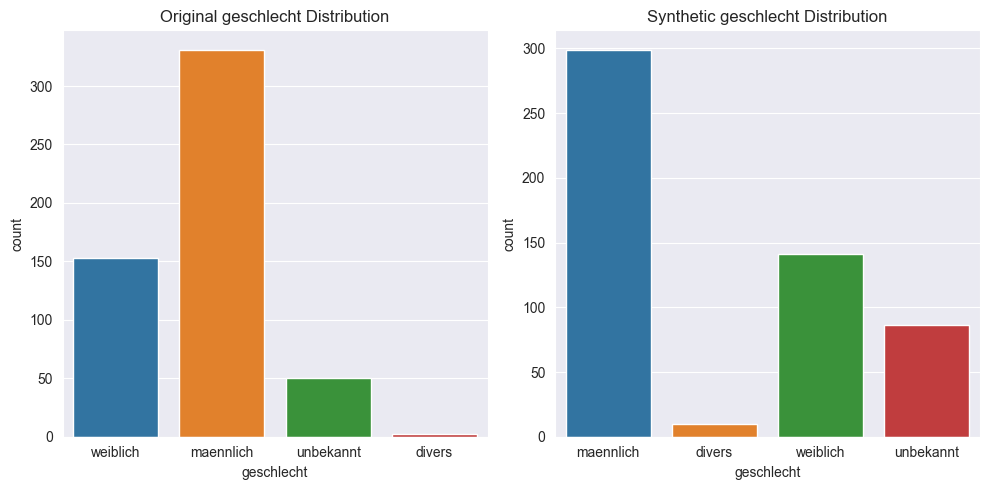

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



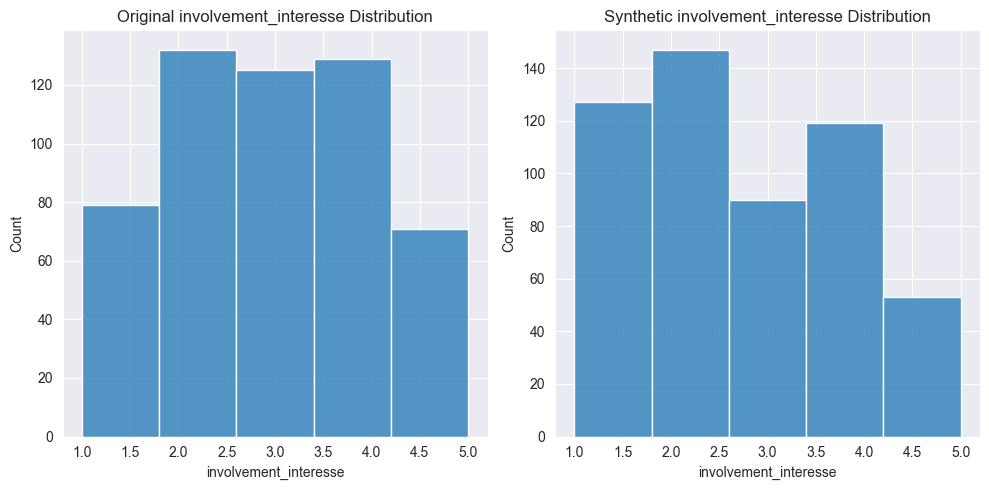

In [3]:
import pandas as pd
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load the dataset
# Assuming your data is in a CSV file named 'dataset.csv'
data = pd.read_csv('../../Usability/data/base_data/CTGAN_basedata.csv')

# Handle missing values or "keine Angabe"
categorical_columns = ['geschlecht', 'bundesland', 'beruf', 'konsumhaeufigkeit']
for col in categorical_columns:
    data[col] = data[col].replace('keine Angabe', np.nan)  # Treat as NaN or keep as category

# Convert 'alter' to numeric, handling "keine Angabe"
data['alter'] = pd.to_numeric(data['alter'], errors='coerce')

# Step 2: Create metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

# Explicitly set column types
for col in categorical_columns:
    metadata.update_column(column_name=col, sdtype='categorical')
metadata.update_column(column_name='alter', sdtype='numerical')  # Remove subtype

# Set ordinal columns (Likert-scale, 1–5) as numerical
ordinal_columns = [col for col in data.columns if col not in categorical_columns + ['alter']]
for col in ordinal_columns:
    metadata.update_column(column_name=col, sdtype='numerical')  # Remove subtype

# Validate metadata
metadata.validate()

# Step 3: Initialize and train the CTGAN model
synthesizer = CTGANSynthesizer(
    metadata=metadata,
    epochs=300,  # Adjust based on dataset complexity
    batch_size=100,
    verbose=True
)

# Fit the model
synthesizer.fit(data)

# Step 4: Generate synthetic data
synthetic_data = synthesizer.sample(num_rows=len(data))  # Generate 536 rows

# Step 5: Post-process synthetic data
# Round and clip ordinal columns to 1–5 and cast to integer
synthetic_data[ordinal_columns] = synthetic_data[ordinal_columns].round().clip(1, 5).astype('Int64')

# Round and clip 'alter' to a realistic range (e.g., 1900–2025 for year of birth)
synthetic_data['alter'] = synthetic_data['alter'].round().clip(1900, 2025).astype('Int64')

# Replace NaN in categorical columns with 'keine Angabe' if desired
for col in categorical_columns:
    synthetic_data[col] = synthetic_data[col].fillna('keine Angabe')

# Step 6: Save synthetic data
synthetic_data.to_csv('synthetic_data.csv', index=False)

# Step 7: Evaluate synthetic data quality
quality_report = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)
print(f"Quality Report Score: {quality_report.get_score()}")
print("\nColumn Shapes Details:")
print(quality_report.get_details(property_name='Column Shapes'))
print("\nColumn Pair Trends Details:")
print(quality_report.get_details(property_name='Column Pair Trends'))

# Step 8: Visualize distributions
# Categorical column example
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='geschlecht', data=data)
plt.title('Original geschlecht Distribution')
plt.subplot(1, 2, 2)
sns.countplot(x='geschlecht', data=synthetic_data)
plt.title('Synthetic geschlecht Distribution')
plt.tight_layout()
plt.show()

# Ordinal column example
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['involvement_interesse'], bins=5)
plt.title('Original involvement_interesse Distribution')
plt.subplot(1, 2, 2)
sns.histplot(synthetic_data['involvement_interesse'], bins=5)
plt.title('Synthetic involvement_interesse Distribution')
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sdv/single_table/base.py:163: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sdv/single_table/base.py:129: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

Gen. (-7.16) | Discrim. (0.39): 100%|██████████| 300/300 [00:45<00:00,  6.62it/s] 


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 60/60 [00:00<00:00, 902.47it/s]|
Column Shapes Score: 85.25%

(2/2) Evaluating Column Pair Trends: |██████████| 1770/1770 [00:02<00:00, 677.13it/s]|
Column Pair Trends Score: 92.99%

Overall Score (Average): 89.12%

Quality Report Score: 0.8912308493549483

Column Shapes Details:
                                    Column        Metric     Score
0                               geschlecht  TVComplement  0.945896
1                                    alter  KSComplement  0.759328
2                               bundesland  TVComplement  0.820896
3                                    beruf  TVComplement  0.899254
4                        konsumhaeufigkeit  TVComplement  0.972015
5                situation_freunde_familie  KSComplement  0.910448
6                          situation_party  KSComplement  0.860075
7                  situation_zuhause_essen  KSComplement  0.783582
8            situation_zuhause_entspannung  KSCo

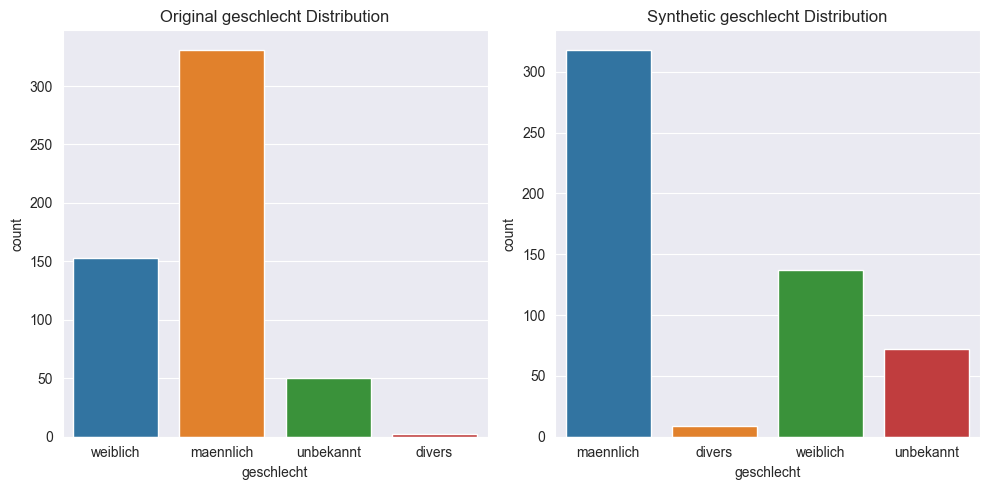

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



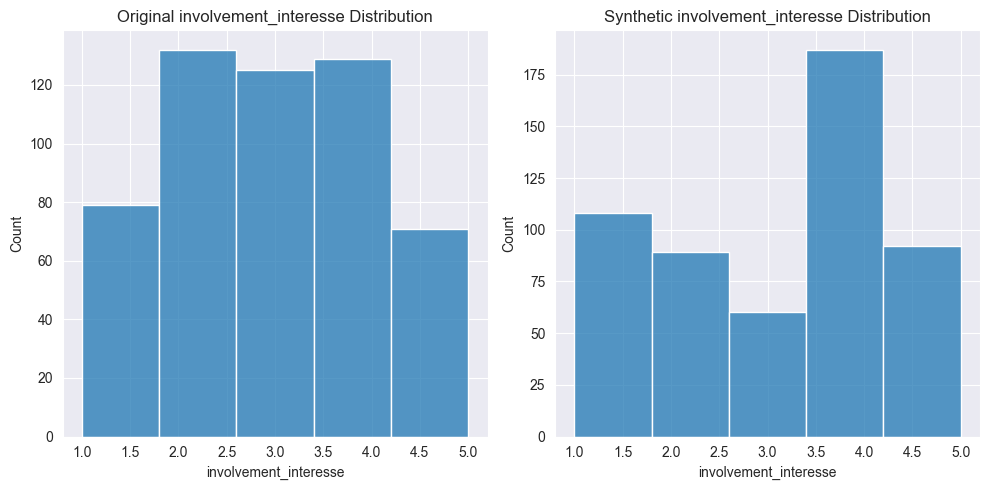

In [5]:
import pandas as pd
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load the dataset
# Assuming your data is in a CSV file named 'dataset.csv'
data = pd.read_csv('../../Usability/data/base_data/CTGAN_basedata.csv')

# Handle 'keine Angabe' for categorical columns with mode
categorical_columns = ['geschlecht', 'bundesland', 'beruf', 'konsumhaeufigkeit']
for col in categorical_columns:
    mode_value = data[col][data[col] != 'keine Angabe'].mode()[0]  # Get mode excluding 'keine Angabe'
    data[col] = data[col].replace('keine Angabe', mode_value)

# Convert 'alter' to numeric and impute 'keine Angabe' with median
data['alter'] = pd.to_numeric(data['alter'], errors='coerce')  # Convert to numeric, 'keine Angabe' becomes NaN
median_alter = data['alter'].median()  # Compute median of valid values
data['alter'] = data['alter'].fillna(median_alter)  # Impute NaN with median

# Step 2: Create metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

# Explicitly set column types
for col in categorical_columns:
    metadata.update_column(column_name=col, sdtype='categorical')
metadata.update_column(column_name='alter', sdtype='numerical')

# Set ordinal columns (Likert-scale, 1–5) as numerical
ordinal_columns = [col for col in data.columns if col not in categorical_columns + ['alter']]
for col in ordinal_columns:
    metadata.update_column(column_name=col, sdtype='numerical')

# Validate metadata
metadata.validate()

# Step 3: Initialize and train the CTGAN model
synthesizer = CTGANSynthesizer(
    metadata=metadata,
    epochs=300,  # Adjust based on dataset complexity
    batch_size=100,
    verbose=True
)

# Fit the model
synthesizer.fit(data)

# Step 4: Generate synthetic data
synthetic_data = synthesizer.sample(num_rows=len(data))  # Generate 536 rows

# Step 5: Post-process synthetic data
# Round and clip ordinal columns to 1–5 and cast to integer
synthetic_data[ordinal_columns] = synthetic_data[ordinal_columns].round().clip(1, 5).astype('Int64')

# Round and clip 'alter' to a realistic range (e.g., 1900–2025 for year of birth)
synthetic_data['alter'] = synthetic_data['alter'].round().clip(1900, 2025).astype('Int64')

# Step 6: Save synthetic data
synthetic_data.to_csv('synthetic_data.csv', index=False)

# Step 7: Evaluate synthetic data quality
quality_report = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)
print(f"Quality Report Score: {quality_report.get_score()}")
print("\nColumn Shapes Details:")
print(quality_report.get_details(property_name='Column Shapes'))
print("\nColumn Pair Trends Details:")
print(quality_report.get_details(property_name='Column Pair Trends'))

# Step 8: Visualize distributions
# Categorical column example
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='geschlecht', data=data)
plt.title('Original geschlecht Distribution')
plt.subplot(1, 2, 2)
sns.countplot(x='geschlecht', data=synthetic_data)
plt.title('Synthetic geschlecht Distribution')
plt.tight_layout()
plt.show()

# Ordinal column example
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['involvement_interesse'], bins=5)
plt.title('Original involvement_interesse Distribution')
plt.subplot(1, 2, 2)
sns.histplot(synthetic_data['involvement_interesse'], bins=5)
plt.title('Synthetic involvement_interesse Distribution')
plt.tight_layout()
plt.show()